In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [2]:
# 최대 표시 행 수
pd.options.display.max_rows = 200    
# 최대 표시 열 수
pd.options.display.max_columns = 13  
# 컬럼 너비 자동 확장
pd.options.display.max_colwidth = None
# 전체 화면에 맞춰 표 폭 조정
pd.options.display.width = 0

### 1. 머신러닝

#### 문제1. 신생아 건강 데이터 분석 (Newborn_Health.csv)
##### 데이터셋은 신생아(체중 1800g 이하, Low Birth Weight) 관련 정보를 포함하며, 연속형 변수 6~7개와 범주형(Yes/No) 변수 8~10개로 구성됩니다.

- 변수 예시:
- 연속형: 출생체중(g), 임신기간(주), 모체연령, 병원입원일수 등
- 범주형: 쌍둥이여부(Yes/No), 제왕절개여부(Yes/No), 신생아호흡곤란증후군(RDS, Yes/No), 생존여부(0: 사망, 1: 생존) 등
- 뇌손상 관련 변수: D, E, F (각각 None, Mild, Severe, NA)
- 종속변수: 생존여부 (survival, 0/1)


각 컬럼에 대한 설명:

Maternal Age (엄마 나이): 출산 당시 엄마의 나이를 의미합니다.

Gestational Age (임신 주수): 임신 기간을 주 단위로 나타냅니다. 예를 들어, 40주는 만삭을 의미합니다. (마지막 월경 첫날부터 현재까지의 기간을 주단위로 계산하여 태아의 성장과 발달단계를 파악하는 중요한 의학적 지표이다.)

Birth Weight (출생 시 체중): 신생아의 출생 당시 체중을 그램(g) 또는 킬로그램(kg) 단위로 나타냅니다.

APGAR Score 1min (아프가 점수 1분): 출생 후 1분에 측정한 아프가 점수입니다. 아프가 점수는 신생아의 건강 상태를 평가하는 지표로, 피부색, 심박수, 반사 반응, 근긴장도, 호흡 등 5가지 항목을 평가하여 총 0점에서 10점까지 매깁니다.

APGAR Score 5min (아프가 점수 5분): 출생 후 5분에 측정한 아프가 점수입니다. 일반적으로 1분 점수보다 5분 점수가 신생아의 장기적인 예후와 더 관련이 깊다고 알려져 있습니다.

Sex (성별): 신생아의 성별을 나타냅니다 (예: 남, 여 또는 M, F).

Presence of Congenital Abnormality (선천성 기형 유무): 신생아에게 선천성 기형이 있는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Mode of Delivery (분만 방식): 분만 방식을 나타냅니다 (예: 자연 분만, 제왕절개 등).

NICU Admission (신생아 중환자실 입원 여부): 신생아가 출생 후 신생아 중환자실(NICU)에 입원했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Respiratory Distress Syndrome (RDS) (호흡곤란 증후군 (RDS) 발생 여부): 신생아에게 호흡곤란 증후군이 발생했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

#### 데이터 특이사항:

- 결측값 비율: 약 10~15%
- BrainDamage 변수의 NA 비율: 약 20%
- Python/R로 분석 가능, sklearn/xgboost 패키지 사용 권장.

In [3]:
df = pd.read_csv('Newborn_Health.csv')
df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,...,e,f,infection,ventilation,gender,survival
0,1,1599.342831,34.798711,26.624109,9,7,...,None,None,No,No,M,1
1,2,1472.347140,33.849267,29.277407,5,5,...,NaN,Mild,No,No,F,0
2,3,1629.537708,32.119261,26.037900,12,8,...,None,None,No,Yes,M,1
3,4,1800.000000,30.706126,28.460192,7,7,...,None,Severe,No,No,F,1
4,5,1453.169325,33.396447,20.531927,7,6,...,Severe,None,No,No,F,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1000 non-null   int64  
 1   birth_weight     1000 non-null   float64
 2   gestational_age  1000 non-null   float64
 3   maternal_age     1000 non-null   float64
 4   hospital_days    1000 non-null   int64  
 5   apgar_score      1000 non-null   int64  
 6   oxygen_days      1000 non-null   int64  
 7   body_temp        1000 non-null   float64
 8   twins            1000 non-null   object 
 9   c_section        1000 non-null   object 
 10  rds              1000 non-null   object 
 11  d                797 non-null    object 
 12  e                794 non-null    object 
 13  f                800 non-null    object 
 14  infection        1000 non-null   object 
 15  ventilation      1000 non-null   object 
 16  gender           1000 non-null   object 
 17  survival       

In [5]:
df.isna().mean()[df.isna().mean() > 0]

d    0.203
e    0.206
f    0.200
dtype: float64

 d, e, f에 약 20%의 결측치 존재, 결측치 비율이 높아 제거를 한다면 상당히 높은 비율의  데이터 결손이 있을 수 있으므로 추후 보간이 필요. 
뇌손상 변수 교차표 생성 시 결측치가 있는 데이터를 그대로 적용하면 오류가 있을 수 있으므로 제외 후 생성

#### 1. 교차표 생성:
- 뇌손상 변수 D, E, F를 두 개씩 조합하여 교차표를 작성하고, 각 조합의 데이터 분포를 추정하시오. (예: D와 E의 교차표, E와 F의 교차표 등)

In [6]:
df_c = df.copy()
df_c = df_c.dropna()

c_list = [('d', 'e'), ('d', 'f'), ('e', 'f')]

for x, y in c_list:
#     cr = pd.crosstab(df_c[x], df_c[y], margins=True)
    pct = pd.crosstab(df_c[x], df_c[y], normalize='all', margins=True) * 100
#     display(cr)
    display(pct.round(1)) #퍼센트

e,Mild,None,Severe,All
d,,,,
Mild,5.0,16.6,2.8,24.4
None,14.6,38.1,7.6,60.3
Severe,4.4,9.0,1.8,15.2
All,24.0,63.7,12.2,100.0


f,Mild,None,Severe,All
d,,,,
Mild,6.8,14.4,3.2,24.4
None,18.4,33.5,8.4,60.3
Severe,4.8,9.2,1.2,15.2
All,30.1,57.1,12.8,100.0


f,Mild,None,Severe,All
e,,,,
Mild,8.4,13.4,2.2,24.0
None,18.2,37.3,8.2,63.7
Severe,3.4,6.4,2.4,12.2
All,30.1,57.1,12.8,100.0


결측치 제거 후 뇌손상변수 3개를 이용하여, 2개씩 짝지어 교차표를 생성하였다.  
- d-e: None->Severe로 갈수록 빈도 비율이 낮아지며, 긴꼬리 분포를 보임
    - d 기준: None에 60.3%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포   
    - e 기준: None에 63.7%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포  
    - 기타: 두 변수 모두 None인 비율이 38.1%로 가장 높으며, Severe-Severe 비율이 1.8%로 가장 낮음    
      대체로 None->Mild일 때 비율이 급격히 하락
      
      
- d-f: None->Severe로 갈수록 빈도 비율이 낮아지며, 긴꼬리 분포를 보임  
    - d 기준: None에 60.3%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포 
    - f 기준: None에 57.1%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포
    - 기타: 두 변수 모두 None인 비율이 33.5%로 가장 높으며, Severe-Severe 비율이 1.2%로 가장 낮음  
      f는 None->Mild, Mild->Servr에서 모두 급격한 비율하락 관찰
      
      
- f-e: None->Severe로 갈수록 빈도 비율이 낮아지며, 긴꼬리 분포를 보임
    - f 기준: None에 60.3%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포 
    - e 기준: None에 57.1%로 중위수 이상의 비율을 차지하여 우측 긴꼬리 분포
    - 기타: 두 변수 모두 None인 비율이 37.3%로 가장 높으며, Severe-Mild 비율이 2.2%로 가장 낮음  
      대체로 None->Mild일 때 비율이 급격히 하락, f가 Severe일 때 Mild->Severe 비율이 미미하게 상승
            
세 변수의 분포는 None->Severe로 갈수록 빈도 비율이 낮아지며, 긴꼬리 분포를 보이므로 분포가 유사하며,   
두 변수 모두 None의 비율이 압도적으로 높으며, Servere가 가장 낮다.

#### 2. 파생변수 생성:
- BrainDamage: D, E, F가 모두 NA이면 0, 하나라도 None/Mild/Severe이면 1, 그 외는 NA로 처리.
- SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리.

In [7]:
m_cols = ['d', 'e', 'f']

cond1 = df[m_cols].isna().all(axis=1)#모두 NA인 경우, 불릿형식이 할당되어야 함
cond2 = df[m_cols].isin(['None', 'Mild', 'Severe']).any(axis=1) #하나라도 None/Mild/Severe 이면 1
df['brain_damage'] = np.where(cond1, 0, np.where(cond2, 1, np.nan)).astype('object')
df['survival'] = df['survival'].astype('object')

df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,...,f,infection,ventilation,gender,survival,brain_damage
0,1,1599.342831,34.798711,26.624109,9,7,...,None,No,No,M,1,1
1,2,1472.347140,33.849267,29.277407,5,5,...,Mild,No,No,F,0,1
2,3,1629.537708,32.119261,26.037900,12,8,...,None,No,Yes,M,1,1
3,4,1800.000000,30.706126,28.460192,7,7,...,Severe,No,No,F,1,1
4,5,1453.169325,33.396447,20.531927,7,6,...,None,No,No,F,0,1


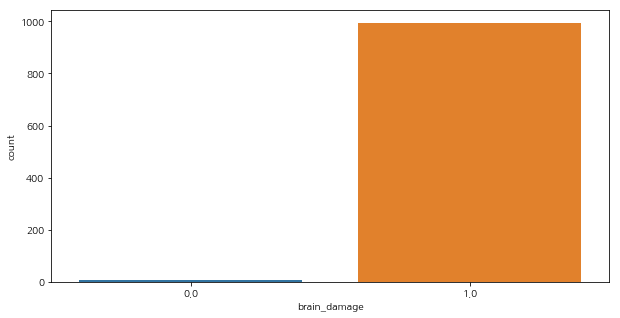

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(df['brain_damage'])
plt.show()

In [9]:
df['brain_damage'].value_counts()

1.0    994
0.0      6
Name: brain_damage, dtype: int64

상당히 불균형한 형태를 띄고있다.

#### 3. 데이터 전처리:
- 결측값 처리: 연속형 변수는 중앙값으로, 범주형 변수는 최빈값으로 대체.
- 불필요한 변수(예: ID, 상수값 변수) 제거.

In [10]:
df[(df['d'] == 'None')&(df['e'] == 'None')&(df['f'] == 'None')]

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,...,f,infection,ventilation,gender,survival,brain_damage
2,3,1629.537708,32.119261,26.037900,12,8,...,None,No,Yes,M,1,1
13,14,1117.343951,30.621624,25.300484,13,9,...,None,No,Yes,F,1,1
16,17,1297.433776,30.697164,28.677426,16,9,...,None,No,No,M,1,1
25,26,1522.184518,32.872647,30.919248,9,6,...,None,Yes,No,M,1,1
32,33,1497.300555,32.798446,32.381789,10,7,...,None,No,No,M,1,1
36,37,1541.772719,29.548469,31.962080,11,7,...,None,No,Yes,M,1,1
51,52,1422.983544,32.791607,25.664349,16,4,...,None,No,Yes,M,1,1
74,75,976.050979,33.992534,26.911741,10,6,...,None,No,No,M,1,1
76,77,1517.409414,28.886836,33.078856,10,7,...,None,No,Yes,F,1,1
105,106,1580.810171,29.920188,38.213365,9,6,...,None,No,No,F,1,1


In [11]:
df.isna().sum()[df.isna().sum()>0]

d    203
e    206
f    200
dtype: int64

In [12]:
cat_cols = df.select_dtypes('O').columns

for col in cat_cols:
    print(f"- 컬럼명: ")
    print(df[col].value_counts())

- 컬럼명: 
No     904
Yes     96
Name: twins, dtype: int64
- 컬럼명: 
No     587
Yes    413
Name: c_section, dtype: int64
- 컬럼명: 
No     675
Yes    325
Name: rds, dtype: int64
- 컬럼명: 
None      496
Mild      199
Severe    102
Name: d, dtype: int64
- 컬럼명: 
None      501
Mild      193
Severe    100
Name: e, dtype: int64
- 컬럼명: 
None      454
Mild      239
Severe    107
Name: f, dtype: int64
- 컬럼명: 
No     803
Yes    197
Name: infection, dtype: int64
- 컬럼명: 
No     720
Yes    280
Name: ventilation, dtype: int64
- 컬럼명: 
F    501
M    499
Name: gender, dtype: int64
- 컬럼명: 
1    813
0    187
Name: survival, dtype: int64
- 컬럼명: 
1.0    994
0.0      6
Name: brain_damage, dtype: int64


명목형 변수 d, f, e 세 개에 대한 결측치 처리만 수행하면 된다. 
최빈값으로 대치한다. 

In [13]:
for col in m_cols:
    gg = df[col].mode()[0]
    print(f"- {col} 최빈값: {gg}")
    df[col] = df[col].fillna(gg)
display(df[m_cols].value_counts())

- d 최빈값: None
- e 최빈값: None
- f 최빈값: None


d       e       f     
None    None    None      324
                Mild      113
Mild    None    None      100
None    Mild    None       92
        None    Severe     58
        Severe  None       43
Severe  None    None       39
None    Mild    Mild       32
Mild    None    Mild       30
Severe  None    Mild       23
None    Severe  Mild       20
Mild    Mild    None       19
Severe  Mild    None       18
Mild    None    Severe     15
        Severe  None       13
None    Mild    Severe     11
Mild    Mild    Mild       10
Severe  Severe  None        6
None    Severe  Severe      6
Severe  Mild    Mild        6
Mild    Severe  Severe      5
Severe  None    Severe      5
Mild    Mild    Severe      4
        Severe  Mild        3
Severe  Severe  Mild        2
                Severe      2
        Mild    Severe      1
dtype: int64

In [14]:
df.drop(columns='id', inplace=True) #불필요 변수 삭제

In [15]:
df.isna().sum()[df.isna().sum()>0] #결측치 없음

Series([], dtype: int64)

#### 4. EDA (탐색적 데이터 분석):
- 생존여부(survival)와 BrainDamage에 따른 주요 변수(출생체중, 임신기간 등)의 분포를 시각화하고 상관관계 분석.

In [16]:
ob_cols = ['survival', 'brain_damage'] #목적변수
n_cols = df.select_dtypes('number').columns.tolist()
c_cols = df.select_dtypes('O').columns.tolist()

def check_dist(ob):
    print(f"<<목적변수: {ob}>>")
    c_cols = df.select_dtypes('O').columns.tolist()
    c_cols.remove(ob)
    mt = df.melt(id_vars=ob, value_vars=n_cols, var_name='variable', value_name='value')
    g = sns.FacetGrid(mt, col='variable', hue=ob, col_wrap=4, sharex=False, sharey=False, height=3, aspect=1.2)
    g.map(sns.kdeplot, 'value', alpha=0.6)
    g.add_legend()
    plt.show()
    mt = df.melt(id_vars=ob, value_vars=c_cols, var_name='variable', value_name='value')
    g = sns.FacetGrid(mt, col='variable', hue=ob, col_wrap=4, sharex=False, sharey=False, height=3, aspect=1.2)
    g.map(sns.countplot, 'value', alpha=0.4)
    g.add_legend()
#     sns.catplot(data=mt, x='value', col='variable', hue=ob, kind='count', col_wrap=4, height=3, aspect=1.2)
    plt.tight_layout()
    plt.show()

<<목적변수: survival>>


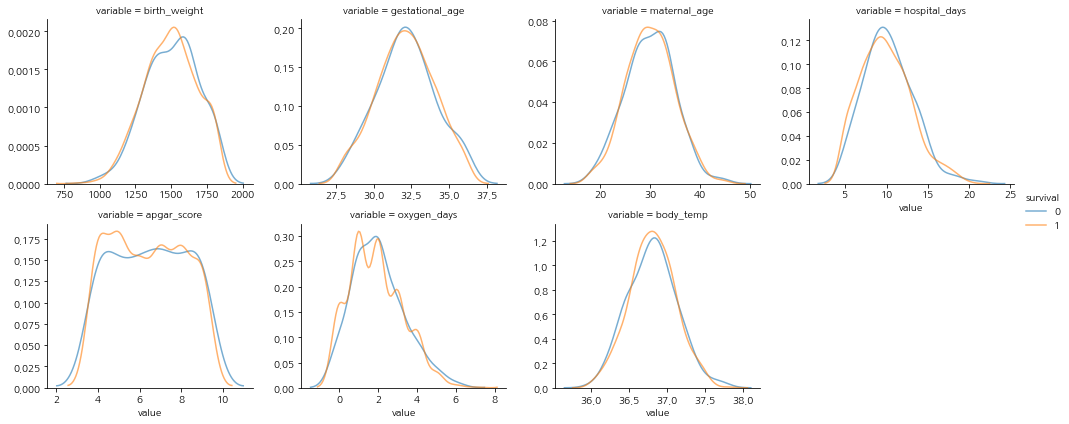

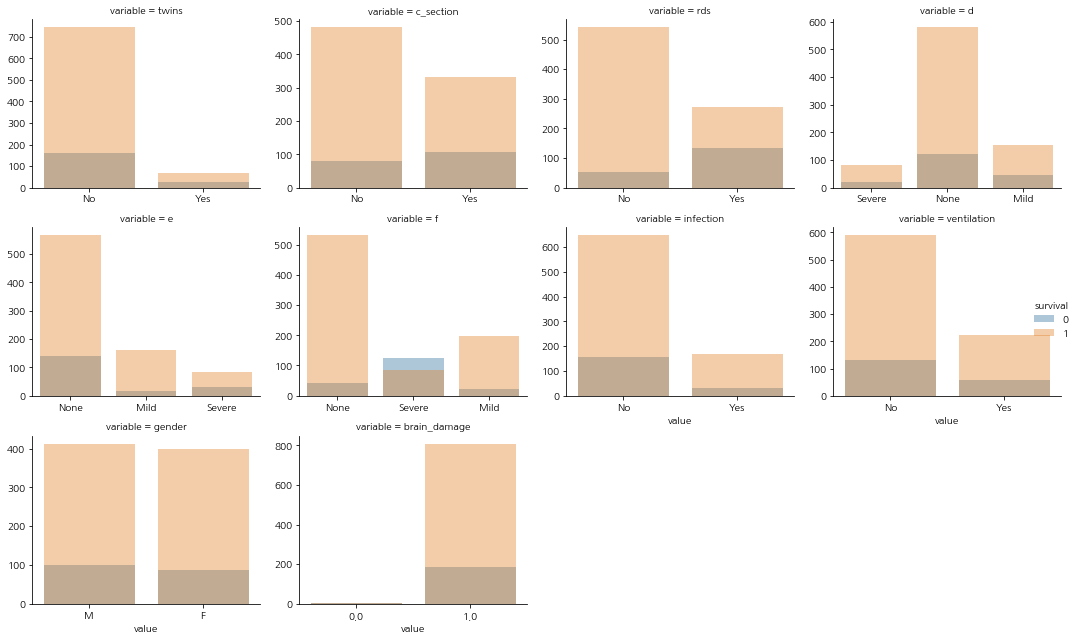

In [17]:
check_dist(ob_cols[0]) # 생존여부에 따른 변수 시각화

- 생존여부에 따른 분포 시각화 
  - 수치형 변수는 생존여부 간 유사한 분포를 보인다. 
  - 우측 긴꼬리 분포: hospital_days, axgan_days(분포불균형 완화를 위한 log 변환 고려)
  - 출생몸무게 1250-1750간 생존한 경우의 비율이 더 높음
  - 병원입원기간 10일인 경우 사망한 비율이 더 높음
  - APGAR Score 4일 경우 생존한 비율이 더 높음
  - 전반적으로 생존비율이 더 높다. 
  - 쌍둥이가 아님, infection no, ventilation yes, (d, e) none 비율이 압도적으로 높음
    (생존영아의 경우 클래스 불균형 정도가 더 심함)
  - f의 경우 사망영아의 severe 비율이 가장 높음, 생존영아의 경우 None이 가장 높음
  - 영아의 성별은 동일한 비율임
  - c section, rds(호흡곤란 관련 변수) 의 경우 사망영아의 실시비율이 높음
  
뇌손상(f, e) 중증도 및 호흡곤란 징후가 있는 영아의 사망확률이 높음

<<목적변수: brain_damage>>


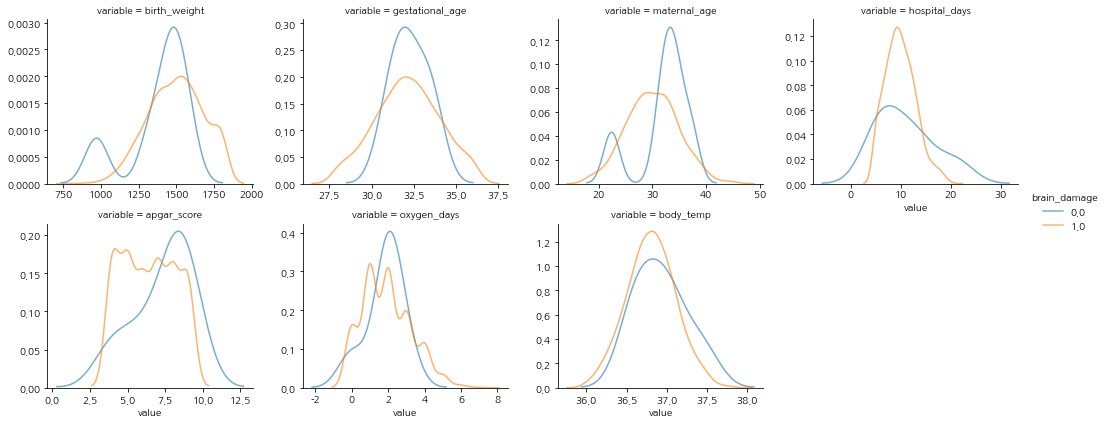

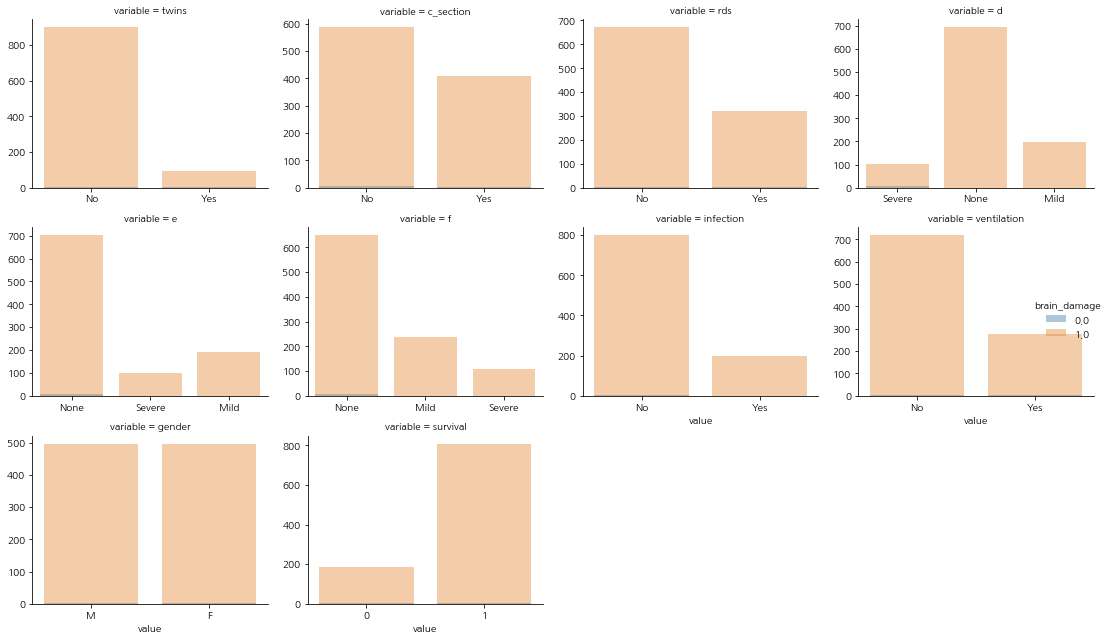

In [18]:
check_dist(ob_cols[1]) # 뇌손상 여부에 따른 변수 시각화

- 뇌손상 여부에 따른 분포 시각화 
  - 뇌손상 영아의 몸무게는 쌍봉분포를 띄는데, 저체중(750-1200), 비교적 일반체중(1200-1750) 구간에 분포
  - 뇌손상 영아의 임신주수 분포 첨도는 30~35 정도로 정상영아보다 더 밀집되어 있다.(첨도 높음)
  - 모체연령 또한 정상영아의 경우 정규분포에 가까운 형태를 띔에 비해 뇌손상 영아의 경우 쌍봉분포를 띄고 있음  
    (특히 고령자 30-40세 비율 높음)
  - 뇌손상 영아의 경우 병원입원기간이 20일을 넘어간다.
  - 아프가 점수의 경우 뇌손상 영아는 왼쪽꼬리 분포로 높은 값을 가진다.
  - 체온은 뇌손상영아의 경우 정상 영아보다 높은 편이다. 
  - 뇌손상 있는 영아의 비율이 압도적으로 높다.
  - 뇌손상 영아 중 살아남은 비율이 높음, 쌍둥이가 아닌 경우가 높음
  - d, e, f none>mild>severe 순으로 빈도 높음
  - infection, ventilation no 비율이 높음
  
뇌손상이 있더라도 살아남은 영아 비율이 높으며, 저체중, 30~35 임신주수에서 뇌손상 가능성이 높다.   
또한 뇌손상 영아의 아프간 점수는 비교적 높은 점수이며, 체온이 일반보다 다소 높다. 그리고 장기간 입원경향을 보인다.

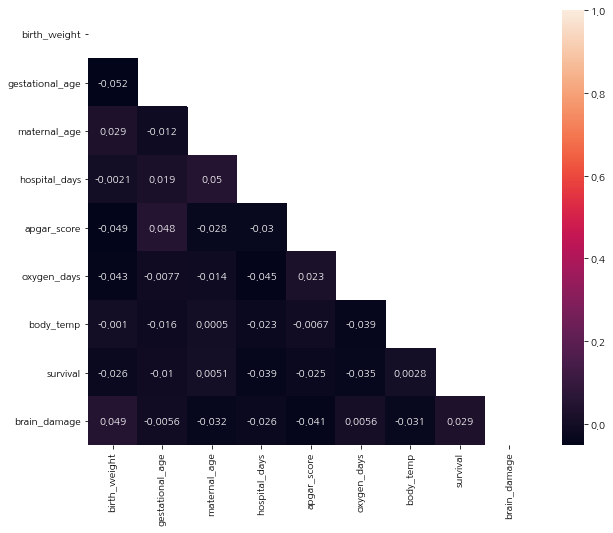

In [19]:
df_rr = df.copy()
df_rr[ob_cols] = df_rr[ob_cols].astype('int')

plt.figure(figsize=(10, 8))
corr = df_rr.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

피어슨 선형 상관분석 간 변수별 유의미한 상관관계는 도출되지 않았다.  
이는 1:1 독립적인 변수 간 다중공선성이 없음을 뜻한다.

- 생존여부별 birth_weight, gestational_age 박스플롯.
- BrainDamage와 survival 간 상관관계(크래머 V 등).

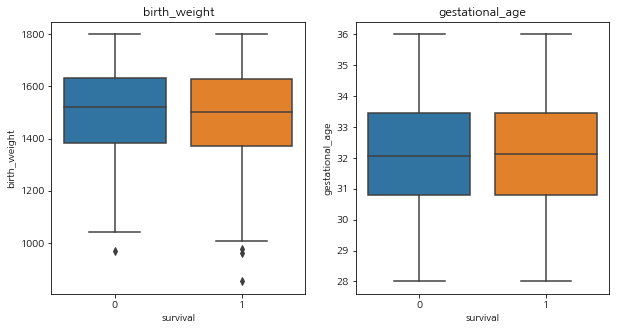

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for col, ax in zip(['birth_weight', 'gestational_age'], ax.flatten()):
    sns.boxplot(data=df, y=col, x='survival', ax=ax)
    ax.set_title(col)
plt.show()

생존여부별 출생몸무게, 임신주수 boxplot 결과  
중앙값 기준으로 사망자의 몸무게가 높으며, 임신주수는 생존영아의 임신주수가 미묘하게 높다.  
사망영아의 몸무게 분포범위가 생존영아에 비해 좁게 분포되어 있다.

In [21]:
# 범주형 변수 간 상관관계 분석: 카이제곱 독립성 검정
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

cr = pd.crosstab(df['survival'], df['brain_damage'])

stat, p, ddof, expected = chi2_contingency(cr)
v = association(cr, method='cramer')

print(f"- 카이제곱 검정통계량: {stat:.3f}")
print(f"- p-value: {p:.3f}")
print(f"- Cramér’s V: {v:.3f}")

- 카이제곱 검정통계량: 0.158
- p-value: 0.691
- Cramér’s V: 0.029


생존여부와 뇌손상 간 카이제곱 독립성 검정을 수행하였다.  
유의수준 5% 하에서 다음과 같이 가설을 수립하였다.  
<가설설정>  
- 귀무: 생존여부와 뇌손상 관계는 독립이다. 
- 대립: 생존여부와 뇌손상 관계는 연관이 있다.  

p-value를 보면 0.158로 귀무가설을 기각할 수 없다.  
따라서 생존여부와 뇌손상 관계는 독립이다. 

연관성 정도를 크레이머 v 점수로 해석하면 0.029로 중간정도의 연관성이 존재한다.  

| Cramér’s V 값 범위       | 연관성 강도 해석      |
|-------------------------|----------------------|
| 0.00 ≤ V < 0.10         | **거의 무시할 수 있음** |
| 0.10 ≤ V < 0.20         | **약한 연관성**        |
| 0.20 ≤ V < 0.40         | **중간 정도 연관성**    |
| 0.40 ≤ V < 0.60         | **상당한 연관성**      |
| 0.60 ≤ V ≤ 1.00         | **강한 연관성**        |

- **거의 무시할 수 있음 (Negligible):** 두 범주형 변수 사이에 실질적인 연관성이 없음 
- **약한 연관성 (Weak):** 연관성은 있지만 예측력이나 설명력은 제한적
- **중간 정도 연관성 (Moderate):** 유의미한 관계가 있으나 다른 변수들도 함께 고려 필요 
- **상당한 연관성 (Relatively Strong):** 변수 간 관계가 뚜렷하며 예측 모델에 유용할 가능성 높음
- **강한 연관성 (Strong):** 두 변수 사이에 매우 밀접한 관계가 있음을 의미

뇌손상(BrainDamage) 변수와 생존여부(Survival)가 통계적으로 독립이며, 중간수준의 연관성이 있으므로 해당 변수를   
포함한 예측 모델 성능저하 시 제외하고 학습하는 것을 고려한다. 

In [22]:
df['survival'].value_counts()

1    813
0    187
Name: survival, dtype: int64

#### 분류 분석:
- 단일 분류: 로지스틱 회귀 또는 의사결정나무를 사용하여 survival 예측.
- 앙상블 분류: 랜덤포레스트와 XGBoost를 사용하여 survival 예측.
- 모델 성능 비교(Accuracy, F1-Score, ROC-AUC).

불균형 데이터이므로 오버샘플링 고려

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import time

X = df.drop(columns=['survival', 'brain_damage'])
Y = df['survival'].astype('int')

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42, stratify=Y)

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

#로지스틱 회귀용
pre = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

#트리형 모델
pre2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)
#로지스틱회귀
lr = Pipeline([
    ('preprocessor', pre), 
    ('classifer', LogisticRegression(random_state=42))
])
#의사결정나무
dt = Pipeline([
    ('preprocessor', pre2), 
    ('classifer', DecisionTreeClassifier(random_state=42))
])
#xgbboost
xgb =  Pipeline([
    ('preprocessor', pre2), 
    ('classifer', XGBClassifier(random_state=42))
])
#랜덤포레스트
rf =  Pipeline([
    ('preprocessor', pre2), 
    ('classifer', RandomForestClassifier(random_state=42))
])

model_list = [('로지스틱 회귀', lr), ('의사결정나무', dt), ('xgb', xgb), ('랜덤포레스트', rf)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['model', 'data', 'acc', 'f1', 'roc_auc', 'time']) #결과

#모델학습 및 평가
for m_name, model in model_list:
    s = time.time()
    model.fit(train_X, train_Y)
    e = time.time() - s
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred)
        roc_auc = roc_auc_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, acc, f1, roc_auc, e]
display(rs)

,model,data,acc,f1,roc_auc,time
0,로지스틱 회귀,train,0.813333,0.897059,0.500000,0.051250
1,로지스틱 회귀,test,0.812000,0.896247,0.500000,0.051250
2,의사결정나무,train,1.000000,1.000000,1.000000,0.005585
3,의사결정나무,test,0.700000,0.818402,0.480086,0.005585
4,xgb,train,0.838667,0.909769,0.567857,0.107627
5,xgb,test,0.816000,0.898230,0.510638,0.107627
6,랜덤포레스트,train,1.000000,1.000000,1.000000,0.179735
7,랜덤포레스트,test,0.812000,0.896247,0.500000,0.179735


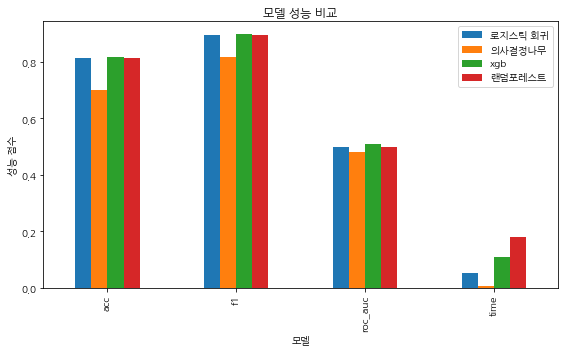

In [34]:
# 모델학습 후 성능비교 시각화
tmp = rs[rs['data'] == 'test'].drop(columns=['data']).T
tmp.columns = tmp.iloc[0].values
tmp = tmp[1:]
ax = tmp.plot(kind='bar', figsize=(8, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('모델')
ax.set_ylabel('성능 점수')
ax.set_title('모델 성능 비교')

plt.tight_layout()
plt.show()

모델 학습 결과 의사결정나무에서 과적합이 발생된 것을 제외하고는 학습/테스트 셋 성능이 균일했다.  
불균형 데이터이므로 f1, roc_auc 점수를 기준으로 test set 성능을 비교하면 xgboost classifier 의 성능이 가장 뛰어남을 알 수 있다.  
다만 실제 사망 영아를 생존으로 오분류한 경우가 대다수임을 알 수 있으므로(roc_auc score 0.5 근방으로 무작위 분류)   
이를 완화하기 위한 오버샘플링 기법 적용이 고려된다. 

- F1 점수: Precision과 Recall의 조화 평균으로, Positive 클래스(사망 영아)에 대한 모델의 식별력을 잘 반영
- ROC AUC: 다양한 분류 임계값에서의 TPR(True Positive Rate)과 FPR(False Positive Rate) 관계를 평가

<개선방안 제안>  
- 오버샘플링 기법: SMOTE, ADASYN 등을 사용해 소수 클래스(사망 영아)의 데이터를 인위적으로 늘림(똑같음)
- 언더샘플링 기법: 다수 클래스(생존) 데이터를 줄여 클래스 비율을 맞춤(부적합, 데이터수 부족)
- 앙상블 및 비용 민감 학습: 비용 민감도(cost-sensitive) 파라미터를 조정하거나, 서로 다른 오버/언더샘플링 모델을 앙상블
- Threshold 조정 및 평가 지표 개선: 분류 임계값을 Recall 중심으로 재조정해 False Negative를 줄이고, Precision-Recall 커브(PR AUC)를 추가로 관찰

### 2. 머신러닝

#### [문제 2] 재생에너지 발전량 예측 (Energy.csv, Climate.csv)
#### 두 데이터셋은 2021~2023년 3년간의 재생에너지 발전량과 기후 데이터를 포함합니다.

- Energy.csv:
- 변수: date(YYYYMMDD), source(태양광/풍력), generation(MWh), hour_0~hour_23(시간별 발전량)
총 발전량(generation)은 태양광과 풍력의 합.
- Climate.csv:
- 변수: date(YYYY-MM-DD), temperature(기온), humidity(습도), windspeed(풍속), precipitation(강수량)
- 일부 변수(temperature, precipitation)에 결측값 존재.

#### 데이터 특이사항:

- Energy.csv: 약 1000일 데이터, 결측값 5% 이하.
- Climate.csv: 약 1100일 데이터, 결측값 10% 내외.
- Python(Pandas, sklearn) 또는 R(dplyr, caret)로 분석 가능.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

energy_df = pd.read_csv('Energy.csv')
climate_df = pd.read_csv('Climate.csv')
energy_df.drop(columns=['generation'], inplace=True, axis=1)
display(energy_df.head())
display(climate_df.head())

,date,source,hour_0,hour_1,hour_2,hour_3,...,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,20210101,Solar,10.612776,18.919571,16.477538,8.827337,...,11.417600,15.073001,10.228990,13.390003,2.489640,9.963013
1,20210101,Wind,7.421830,5.520150,13.688934,19.836831,...,13.648189,4.026717,7.523877,19.683184,10.749592,0.637982
2,20210102,Solar,16.843117,7.082532,17.834894,5.903762,...,12.665406,12.035176,11.307375,17.278912,6.939721,2.568380
3,20210102,Wind,6.527484,4.081912,25.683430,15.869641,...,1.396033,12.943102,8.819983,10.153434,14.098082,14.236364
4,20210103,Solar,11.144246,13.060810,17.157265,17.923698,...,9.818225,2.075185,17.261561,12.466698,16.477671,15.787612


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203


#### 2. 결측값 처리:
- temperature, precipitation은 결측값을 0으로 대체.
- 그 외 변수(humidity, windspeed 등)는 직전 값(Forward Fill)으로 대체.

In [36]:
climate_df.isna().sum()[climate_df.isna().sum()>0]
energy_df.isna().sum()[energy_df.isna().sum()>0]

hour_0     106
hour_1     106
hour_2     106
hour_3     106
hour_4     106
hour_5     106
hour_6     106
hour_7     106
hour_8     106
hour_9     106
hour_10    106
hour_11    106
hour_12    106
hour_13    106
hour_14    106
hour_15    106
hour_16    106
hour_17    106
hour_18    106
hour_19    106
hour_20    106
hour_21    106
hour_22    106
hour_23    106
dtype: int64

In [37]:
climate_df = climate_df.fillna(0) #temperature, precipitation 결측값 0대치
energy_df = energy_df.fillna(method='ffill') #이외 직전 값으로 보간

print(climate_df.isna().sum()[climate_df.isna().sum()>0])
print(energy_df.isna().sum()[energy_df.isna().sum()>0])

Series([], dtype: int64)
Series([], dtype: int64)


In [38]:
climate_df['date'] = pd.to_datetime(climate_df['date'], format='%Y-%m-%d')
energy_df['date'] = pd.to_datetime(energy_df['date'], format='%Y%m%d')

In [39]:
energy_df= energy_df.melt(id_vars=['date', 'source'], var_name='time', value_name='generation')
energy_df['time'] = energy_df['time'].str.replace('hour_', '').astype(int)
display(energy_df.head())

,date,source,time,generation
0,2021-01-01,Solar,0,10.612776
1,2021-01-01,Wind,0,7.421830
2,2021-01-02,Solar,0,16.843117
3,2021-01-02,Wind,0,6.527484
4,2021-01-03,Solar,0,11.144246


#### 3. 파생변수 생성:
- Season: 월을 기준으로 계절 변수 생성 (3-5월: 봄, 6-8월: 여름, 9-11월: 가을, 12-2월: 겨울).

In [40]:
climate_df['date'] = pd.to_datetime(climate_df['date'], format='%Y-%m-%d')
energy_df['date'] = pd.to_datetime(energy_df['date'], format='%Y%m%d')
climate_df['month'] = climate_df['date'].dt.month

cond1 = (climate_df['month'].isin(np.arange(3, 6)))
cond2 = (climate_df['month'].isin(np.arange(6, 9)))
cond3 = (climate_df['month'].isin(np.arange(9, 11)))

climate_df['season'] = np.where(cond1, '봄', 
                                np.where(cond2, '여름', 
                                         np.where(cond3, '가을', '겨울')))

display(climate_df.head())
display(energy_df.head(3))

,date,temperature,humidity,windspeed,precipitation,month,season
0,2021-01-01,8.196357,60.767346,7.229558,0.133543,1,겨울
1,2021-01-02,7.842254,71.605808,1.878436,3.203037,1,겨울
2,2021-01-03,8.548918,46.904014,4.651294,2.122495,1,겨울
3,2021-01-04,25.446324,87.003296,0.126070,2.307601,1,겨울
4,2021-01-05,14.434452,52.582675,3.209874,0.562203,1,겨울


,date,source,time,generation
0,2021-01-01,Solar,0,10.612776
1,2021-01-01,Wind,0,7.421830
2,2021-01-02,Solar,0,16.843117


In [41]:
len(climate_df), len(energy_df)

(1095, 52560)

In [42]:
dat = pd.merge(energy_df, climate_df, how='left', on='date')
dat.head()

,date,source,time,generation,temperature,humidity,windspeed,precipitation,month,season
0,2021-01-01,Solar,0,10.612776,8.196357,60.767346,7.229558,0.133543,1,겨울
1,2021-01-01,Wind,0,7.421830,8.196357,60.767346,7.229558,0.133543,1,겨울
2,2021-01-02,Solar,0,16.843117,7.842254,71.605808,1.878436,3.203037,1,겨울
3,2021-01-02,Wind,0,6.527484,7.842254,71.605808,1.878436,3.203037,1,겨울
4,2021-01-03,Solar,0,11.144246,8.548918,46.904014,4.651294,2.122495,1,겨울


In [43]:
dat.drop(columns='month', inplace=True)

In [44]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52560 entries, 0 to 52559
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           52560 non-null  datetime64[ns]
 1   source         52560 non-null  object        
 2   time           52560 non-null  int32         
 3   generation     52560 non-null  float64       
 4   temperature    52560 non-null  float64       
 5   humidity       52560 non-null  float64       
 6   windspeed      52560 non-null  float64       
 7   precipitation  52560 non-null  float64       
 8   season         52560 non-null  object        
dtypes: datetime64[ns](1), float64(5), int32(1), object(2)
memory usage: 3.8+ MB


#### 4. 탐색적 분석:
- 변수 간 상관관계 분석(예: generation과 temperature, windspeed 간 상관계수).
- 계절별 발전량 분포 시각화.

수치형 변수 간 상관관계 분석을 수행한다.  
보편적으로 많이 사용하는 피어슨 선형 상관관계 분석을 실시한다. 

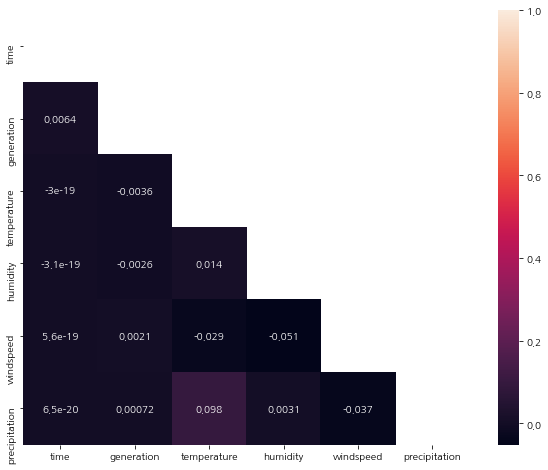

In [45]:
plt.figure(figsize=(10, 8))
corr = dat.corr() 
mask = np.triu(np.ones_like(corr,dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

종속변수인 generation과 설명변수간의 1:1 선형 상관관계 분석 후 유의미한 상관관계가 존재하지 않는 것을 확인했다.   
이는 종속변수와 설명변수 간 유사한 선형 특징이 없음(다중공선성 없음)을 의미한다.

<Figure size 720x504 with 0 Axes>

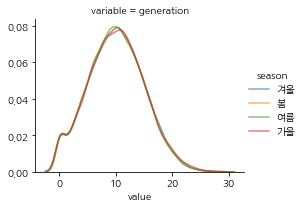

In [46]:
plt.figure(figsize=(10, 7))
mt = dat.melt(id_vars='season', value_vars='generation', var_name='variable', value_name='value')
g = sns.FacetGrid(mt, col='variable', hue='season', col_wrap=1, sharex=False, sharey=False, height=3, aspect=1.2)
g.map(sns.kdeplot, 'value', alpha=0.6)
g.add_legend()
plt.show()

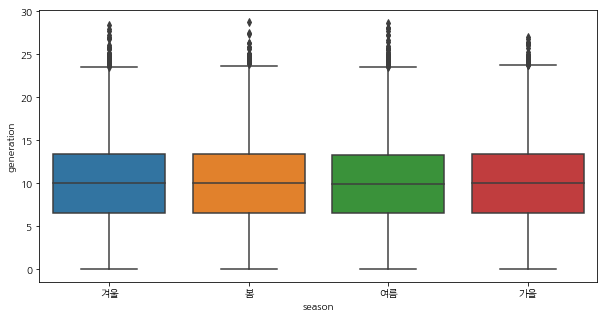

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=dat, y='generation', x='season')
plt.show()

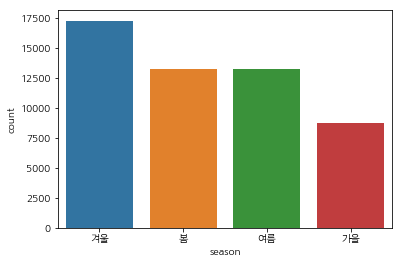

In [48]:
sns.countplot(dat['season'])
plt.show()

겨울>여름>봄>가을 순으로 데이터 수가 많으며,  각 계절별 발전량 분포는 비슷하다. 

#### 5. 데이터 분할 및 예측:
- 2021~2022년 데이터를 학습(train), 2023년 데이터를 테스트(test)로 분할.
- 선형회귀, 랜덤포레스트를 사용하여 총 발전량(generation) 예측.
- 성능 평가: RMSE, R².

In [49]:
# 데이터 분할
train = dat[dat['date'].dt.year.between(2021, 2022)]
test = dat[dat['date'].dt.year > 2022]

train.drop('date', axis=1, inplace=True)
test.drop('date', axis=1, inplace=True)

print(f"학습/테스트 셋 데이터 크기: {len(train)} / {len(test)}")

train_X, train_Y = train.drop('generation', axis=1), train['generation']
test_X, test_Y = test.drop('generation', axis=1), test['generation']

학습/테스트 셋 데이터 크기: 35040 / 17520


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import r2_score, mean_squared_error
import time

# 선형회귀용
n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

#트리용
pre1 = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

#트리형 모델
pre2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

lin =  Pipeline([
    ('preprocessor', pre1), 
    ('rg', LinearRegression())
])

rf =  Pipeline([
    ('preprocessor', pre1), 
    ('rg', RandomForestRegressor(random_state=42))
])

model_list = [('선형회귀', lin), ('랜덤포레스트회귀', rf)]
dt_list = [('학습데이터', train_X, train_Y), ('테스트데이터', test_X, test_Y)]

rs = pd.DataFrame(columns = ['model', 'data', 'time', 'rmse', 'r2'])

for m_name, model in model_list:
    s = time.time()
    model.fit(train_X, train_Y)
    e = time.time() - s
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2 = r2_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, e, rmse, r2]
display(rs)

,model,data,time,rmse,r2
0,선형회귀,학습데이터,0.048940,4.897310,0.000060
1,선형회귀,테스트데이터,0.048940,4.918744,-0.000310
2,랜덤포레스트회귀,학습데이터,12.676495,1.949130,0.841605
3,랜덤포레스트회귀,테스트데이터,12.676495,5.028711,-0.045537


두 모델의 학습 결과이다. rmse, r2를 비교하면 두 척도 모두 선형회귀가 우수한 성능을 보여주었다.  
랜덤포레스트 회귀의 경우 학습데이터에 비해 테스트 데이터의 성능이 저하되는 과적합을 보여주고 있다.  
선형회귀의 경우 일반화된 성능을 보여주고 있으며, 학습시간도 확연히 짧으므로 이번 문제에서 효율적인 모델이다.   
다만,r2값이 음수로 매우 낮은 값을 보여 모델의 설명력이 낮음을 알 수 있다. 

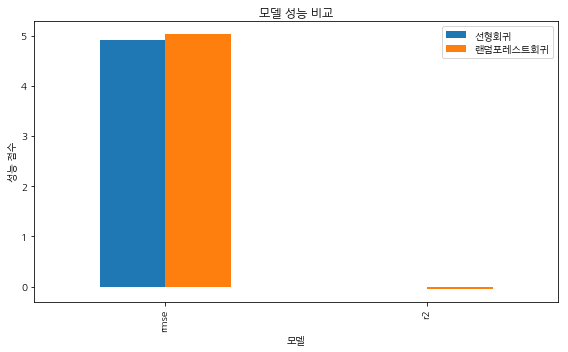

In [52]:
# 모델학습 후 성능비교 시각화
tmp = rs[rs['data'] == '테스트데이터'].drop(columns=['data', 'time']).T
tmp.columns = tmp.iloc[0].values
tmp = tmp[1:]

ax = tmp.plot(kind='bar', figsize=(8, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('모델')
ax.set_ylabel('성능 점수')
ax.set_title('모델 성능 비교')

plt.tight_layout()
plt.show()

### 3. 통계분석

#### [문제 3] 분산분석: 학습방법과 성별에 따른 성적 분석
#### 데이터셋은 학생 40명(남 20, 여 20)의 학습방법(3가지)별 성적을 포함합니다.
##### 변수:
- ID: 학생 식별자
- Gender: 성별 (M/F)
- LearningMethod: 학습방법 (Traditional, Online, Blended)
- Score: 성적 (0~100점)
##### 데이터 특이사항:
- 성적 분포: 평균 75, 표준편차 10 내외.
- Python(statsmodels) 또는 R(aov, TukeyHSD) 사용 권장.

In [53]:
dat = pd.read_csv('./Learning_Score.csv')
display(dat.head())
dat.info()

,id,Gender,Traditional,Online,Blended
0,1,M,89,65,58
1,2,M,73,82,76
2,3,M,80,82,74
3,4,M,83,50,93
4,5,M,78,56,86


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           40 non-null     int64 
 1   Gender       40 non-null     object
 2   Traditional  40 non-null     int64 
 3   Online       40 non-null     int64 
 4   Blended      40 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


해당문제는 종속변수(점수)는 연속형 데이터이며, 1개의 독립요인(성별, between 요인)과 3그룹의 반복측정 요인(학습방법, within 요인)으로 구성된 혼합설계 분산분석이다.  
평균과 표준편차를 모수로 가정하고 있으므로 모수검정을 시행할 수 있다. 

#### 1. 가정 검토:
혼합설계 분산분석은 잔차의 독립성, 정규성, 구형성(within 요인에만), 등분산성을 가정한다.  
모델학습 후 잔차 분석이 적합하다고 판단되지만, 탐색적 목적으로 데이터에 대해 분석을 실시한다.  

먼저 유의수준 5% 하에서 정규성과 등분산성 검정을 시행하고, 모델학습 이후 summary를 통해 구형성 만족여부를 확인한다.  
수집된 데이터이므로 독립성은 만족하는 것으로 가정한다.   
(추후 잔차를 통하여 더빈왓슨 test 가능)

- 정규성 검정(Shapiro-Wilk 테스트)
    - 귀무가설: 각 그룹(6개)은 정규분포를 따른다. 
    - 대립가설: 각 그룹(6개)은 정규분포를 따르지 않는다.

- 등분산 검정(Levene 테스트).
    - 귀무가설: 성별 그룹 간 등분산이다. 
    - 대립가설: 성별 그룹 간 이분산이다.

- 구형성: 모델학습 후 Greenhouse-Geisser 확인
  (수준 간 차이의 분산이 동일, 공분산 행렬이 구형)
  * 0.95 이상이면 거의 완벽, 0.75 이상이면 대체로 충족, 이하는 보정적용, 0.5 미만이면 비모수 대안 고려

In [54]:
from scipy.stats import shapiro, levene

mt = dat.melt(id_vars=['id', 'Gender'], var_name='l_method')
#정규성 검정을 위한 그룹
gr1 = [g['value'].values for name, g in mt.groupby(['Gender', 'l_method'])]

#정규성 검정
for i, g in enumerate(gr1):
    stat1, p1 = shapiro(g)
    print(f"{i+1} 그룹 정규성 검정: {p1:.3f}", "정규성만족" if p1>0.05 else "불만족")

#등분산성 검정
gr2 = [g['value'].values for name, g in mt.groupby(['Gender'])]

stat2, p2 = levene(*gr2)
print(f"levene 등분산성 검정결과: {p2:.3f}", "만족" if p>0.05 else "불만족")

1 그룹 정규성 검정: 0.339 정규성만족
2 그룹 정규성 검정: 0.094 정규성만족
3 그룹 정규성 검정: 0.476 정규성만족
4 그룹 정규성 검정: 0.566 정규성만족
5 그룹 정규성 검정: 0.115 정규성만족
6 그룹 정규성 검정: 0.886 정규성만족
levene 등분산성 검정결과: 0.638 만족


유의수준 5% 하에서 shapiro, levene 검정을 통해 데이터의 정규성, 등분산성 여부를 검정결과  

- 6개 그룹(within 3 * between:2): 모두 정규성을 만족
- between 그룹(성별) 간: 등분산성을 만족한다.  

따라서 혼합설계 모형을 사용하기 위한 근거가 충분하다.   
단, 모델학습 후 within 요인 간 구형성을 확인한다.

#### 2. 분산분석:
- 성별(Gender)과 학습방법(LearningMethod)의 주효과 및 상호작용 효과 분석 (mixed ANOVA, 만약 between간 유의하지 않으면 반복측정).

가설설정 후 주효과와 교호작용 효과에 대한 분석을 실시한다.  

1. 성별 주효과(between)
   - 귀무가설: 성별 그룹 간 평균 성적 차이는 없다. 
   - 대립가설: 성별 그룹 간 평균 성적 차이가 있다. 

2. 학습방법 주효과(within)
    - 귀무가설: 학습방법 그룹 간 평균 성적 차이는 없다. 
    - 대립가설: 적어도 한 학습방법 그룹 간 평균성적 차이가 있다. 
    
3. 교호작용 효과
    - 귀무가설: 성별과 학습방법은 독립적이다.
    - 대립가설: 성별과 학습방법 간 연관성이 있다. 
    
유의수준 5% 하에서 검정을 실시한다.

In [70]:
import pingouin as pg

model = pg.mixed_anova(dv='value', within='l_method', between='Gender', subject='id', data=mt)

display(model)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Gender,0.033333,1,38,0.033333,0.000260,9.872168e-01,0.000007,NaN
1,l_method,4539.216667,2,76,2269.608333,22.577354,2.013656e-08,0.372703,0.995929
2,Interaction,118.816667,2,76,59.408333,0.590976,5.563113e-01,0.015314,NaN


먼저 within 요인인 학습방법의 eps GG 점수가 0.995929로 1에 가까우므로 구형성을 만족한다.  
이로써 혼합설계 분산분석을 사용하기 위한 모든 가정을 만족한다.   
교호작용부터 확인해보면, 보정된 p-value가 0.5563113이므로 귀무가설을 기각할 수 없다. 따라서 성별과 학습방법은 독립적이다.  

교호작용이 없으므로 주효과 분석을 신뢰성있게 수행할 수 있다.  

1. Gender(between 요인): 보정된 p-value가 0.9872168이므로 귀무가설을 기각할 수 없다. 따라서 성별과 학습방법은 독립적이다.  

2. 학습방법(within 요인): 보정된 p-value가 2.013656e-08로 0.05보다 크게 작으므로 귀무가설을 기각한다.  
   따라서 적어도 한 학습방법 그룹 간 평균성적 차이가 있다.라는 대립가설은 통계적으로 유의하다. 

이후 어떤 학습방법 간 평균성적 차이가 있는지 tukey HSD를 통해 사후분석을 수행한다.  

결국은 between 요인이 통계적으로 유의하지 않았으므로 일원배치 반복측정 분산분석과 동일한 분석이라고 할 수 있다. 

#### 3. 사후분석:
- 유의미한 효과가 발견될 경우, Tukey HSD 테스트로 사후분석 수행.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -14.525    0.0 -20.0399 -9.0101   True
Blended Traditional     -3.8 0.2348  -9.3149  1.7149  False
 Online Traditional   10.725    0.0   5.2101 16.2399   True
-----------------------------------------------------------


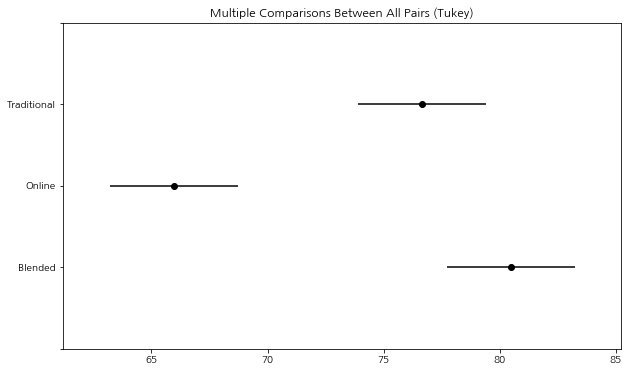

In [56]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 학습방법 사후검정
rs = pairwise_tukeyhsd(endog=mt['value'], groups=mt['l_method'], alpha=0.05)
print(rs)
rs.plot_simultaneous()
plt.show()

#### 4. 결과 해석:
- 각 효과의 p-value와 통계적 유의성 논의.
- 학습방법별 평균 성적 비교 시각화.

Blended-Online(p-value: 0), Online-Traditional(p-value: 0.0) 간에는 통계적으로 유의한 점수평균 차이가 존재한다고 할 수 있으며,  
Blended-Traditional(0.2348) 간에는 유의미한 평균점수 차이가 없다고 할 수 있다.    
중앙값을 기준으로 본다면 온라인 교육의 평균점수는 65점으로 가장 낮으며, Blended가 80점 이상으로 가장 높다.  

하지만 Blended-Traditional간에는 통계적으로 유의한 평균점수 차가 없기 때문에 온라인 교육을 수강 중이라면 점수 향상을 위해  
Blended-Traditional 두 방법 중 비용, 시간 등 기타 요인을 고려하여 선택하는 것이 적절할 것이다. 

### 4. 통계분석

#### [문제 4] 회귀분석: 학업 성취도 예측

#### 데이터셋은 학생 500명의 학업 관련 변수를 포함하며, 국어 성적을 예측하는 회귀분석을 수행합니다.

- 변수:
- ID: 학생 식별자
- StudyTime: 주간 공부시간 (0: 10시간 이하, 1: 1115시간, 2: 1620시간, 3: 21~25시간, 4: 26시간 이상)
- Tutoring: 과외 여부 (Yes/No)
- OnlineCourse: 온라인 강의 수강 여부 (Yes/No)
- Absences: 결석 일수 (평균 4, Q3: 8, 최대 25)
- Failures: 낙제 횟수 (0~3)
- Score: 국어 성적 (0~20점)
#### 데이터 특이사항:
- 결측값: 약 5% (Absences, Failures 중심).
- 범주형 변수(Tutoring, OnlineCourse)는 더미 변수로 변환 필요.
- Python(sklearn, statsmodels) 또는 R(lm, randomForest) 사용 권장.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Academic_Performance.csv')
df.head()

,id,StudyTime,Tutoring,OnlineCourse,Absences,Failures,Score
0,1,3,Yes,Yes,8.0,0.0,12
1,2,1,Yes,Yes,4.0,2.0,11
2,3,1,Yes,No,7.0,1.0,14
3,4,2,No,No,7.0,1.0,14
4,5,0,No,Yes,5.0,1.0,11


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            500 non-null    int64  
 1   StudyTime     500 non-null    int64  
 2   Tutoring      500 non-null    object 
 3   OnlineCourse  500 non-null    object 
 4   Absences      475 non-null    float64
 5   Failures      475 non-null    float64
 6   Score         500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [59]:
df.isna().mean()

id              0.00
StudyTime       0.00
Tutoring        0.00
OnlineCourse    0.00
Absences        0.05
Failures        0.05
Score           0.00
dtype: float64

약 5%의 결측치가 관찰된다. 전체 데이터에서 큰 비중을 차지하지 않으며 수집된 데이터로 보간하는 것은 시간/비용 효율적이지 않고  
데이터 지식을 정확히 모르는 상태에서 보간한다면 데이터의 왜곡이 발생할 수 있으므로 삭제한다. 

In [60]:
df = df.dropna()

#### 가정 검토:
선형회귀 가정(선형성, 정규성, 등분산, 독립성) 검토.
잔차 플롯 및 Q-Q 플롯 시각화


모델의 잔차를 이용해서 선형회귀 가정을 하는 것이 가장 정확하므로 우선 선형회귀 모델 적합 후 잔차를 통해 선형성, 정규성, 등분산성, 독립성을 검정한다.

- 선형성: 잔차-예측값 산점도
- 정규성: shapiro-wilk 검정 및 qq-plot
- 등분산성: breuch-pagan 검정
- 독립성: durbin-watson 검정

In [61]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(formula='Score~StudyTime+C(Tutoring)+C(OnlineCourse)+Absences+Failures', 
               data=df).fit()

<<잔차분석>>


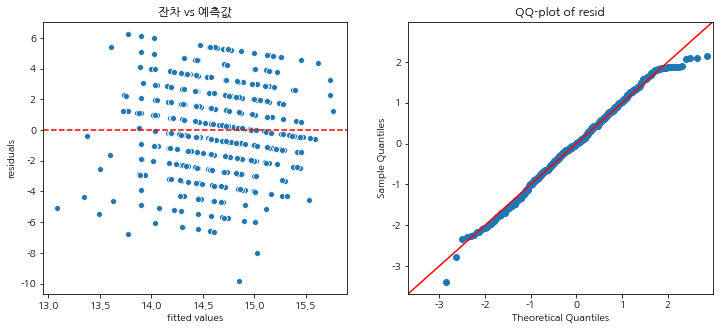

shapiro-wilk 검정 통계랑: 0.993 / p-value: 0.019
breusch-pagan 검정 통계량: 11.142 / p-value: 0.049
더빈왓슨 검정결과: 2.2384905480490853


In [62]:
from scipy.stats import probplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

print("<<잔차분석>>")
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#잔차-적합값 산점도(등분산성/선형성 확인)
sns.scatterplot(x=fitted, y=resid, ax=ax[0])
ax[0].axhline(0, color='r', ls='--')
ax[0].set_xlabel('fitted values')
ax[0].set_ylabel('residuals')
ax[0].set_title('잔차 vs 예측값')

#qq-plot: 정규성 확인
# probplot(resid, plot=ax[1])
sm.qqplot(resid, line='45', fit=True, ax=ax[1])
ax[1].set_title("QQ-plot of resid")
plt.show()

#샤피로-윌크 검정: 정규성
stat, p = shapiro(resid)
print(f"shapiro-wilk 검정 통계랑: {stat:.3f} / p-value: {p:.3f}")

#breusch-pagan 검정: 등분산성
stat, p, _, _ = het_breuschpagan(resid, model.model.exog)
print(f'breusch-pagan 검정 통계량: {stat:.3f} / p-value: {p:.3f}')

#독립성 검정(자기상관여부): 더빈왓슨 검정
print(f"더빈왓슨 검정결과: {durbin_watson(resid)}")

- 선형성: 잔차-예측값 산점도 상 잔차가 무작위로 퍼지지 않았으므로 불만족(패턴보임)
- 정규성: qq-plot 결과, 상단에서 선을 벗어나는 구간이 식별되었고, shapiro-wilk 검정결과 p-value 0.019로 귀무가설을 기각하므로 정규성 불만족
- 등분산성: breusch-pagan 검정결과, p-value: 0.049로 구무가설을 기각하므로 등분산성 불만족
- 독립성: 더빈왓슨 검정결과 2에 가까운 값으로 독립성 만족(통상 1.5–2.5 범위) 

=> 따라서 선형회귀분석의 기본가정을 대체로 만족하지 않으므로 해당 모델 사용은 부적절함(선형성, 정규성, 등분산성 위배)

#### 회귀분석:
선형회귀분석 수행(종속변수: Score, 독립변수: StudyTime, Tutoring, OnlineCourse, Absences, Failures).
기계학습 모델(예: 랜덤포레스트)과 비교.

In [63]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.206
Date:                Tue, 16 Sep 2025   Prob (F-statistic):             0.0526
Time:                        00:15:20   Log-Likelihood:                -1179.1
No. Observations:                 475   AIC:                             2370.
Df Residuals:                     469   BIC:                             2395.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 14

In [64]:
from scipy.stats import chi2
#우도비검정
llf = model.llf
n_model = smf.ols('Score~1', data=df).fit()
llnull = n_model.llf

stat = round(-2*(llnull - llf), 3)
ddof = model.df_model - n_model.df_model

p = chi2.sf(stat, ddof)

print(f"검정통계량: {stat}")
print(f"p-value: {p:.3f}")

검정통계량: 11.044
p-value: 0.051


모델의 설명력(0.023, 약 2.3%), 수정된 설명력(0.013, 약 1.3%)로 전체 데이터 분산을 잘 설명하지 못함.  
모델 전체의 F-검정(p = 0.0526)과 우도비 검정(p = 0.051) 모두 유의수준 5%에서 귀무가설(“모든 회귀계수는 0이다”)을   
기각하지 못하므로, 회귀계수들이 통계적으로 유의하지 않음

#### 다중공선성:
VIF(Variance Inflation Factor) 계산 및 다중공선성 평가.

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = model.params.keys().tolist()
vif['vif'] = [variance_inflation_factor(model.model.exog, i) for i in range(len(model.params.keys().tolist()))]

display(vif[1:])

,name,vif
1,C(Tutoring)[T.Yes],1.009060
2,C(OnlineCourse)[T.Yes],1.016488
3,StudyTime,1.032950
4,Absences,1.015817
5,Failures,1.015863


모든 변수의 vif가 1에 가까우므로 다중공선성이 관찰되지 않는다.  
보통 5 이상~10 미만의 값을 중등수준의 다중공선성이 있다고 보고, 10 이상을 다중공선성으로 판단한다.

In [66]:
#랜덤포레스트 회귀모델 적합
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(['Score', 'id'], axis=1)
Y = df['Score']

X = pd.get_dummies(X, drop_first=True)

rf = RandomForestRegressor()
rf.fit(X, Y)

RandomForestRegressor()

#### 변수 중요도:
회귀계수의 p-value를 통해 통계적 유의성 확인.
랜덤포레스트의 feature importance 분석.

앞서 적합한 선형회귀모델의 p-value 기준으로 귀무가설을 기각하지 못했으며, 우도비 검정결과  
회귀계수는 통계적으로 유의하지 않다. 만약 모델의 회귀계수가 유의하다면  
각 featuere의 p-value 기준으로 C(Tutoring)[T.Yes], Absences가 유의하다고 할 수 있다.  

In [67]:
np.exp(model.params).round(2)

Intercept                 2503624.85
C(Tutoring)[T.Yes]              1.74
C(OnlineCourse)[T.Yes]          0.75
StudyTime                       1.13
Absences                        0.87
Failures                        1.18
dtype: float64

만약 회귀계수가 통계적으로 유의하다면 오즈비 검정을 통해 종속변수 발생확률을 추정할 수 있다.  
- 결석이 1회 증가할 때마다 국어성적은 13% 하락
- 과외를 하지 않는 것에 비해 과외를 하는 경우의 오즈가 약 74% 증가

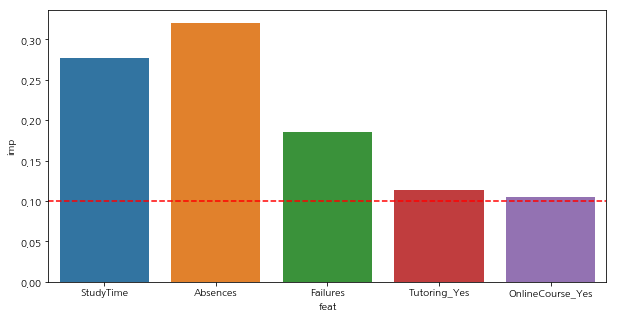

In [68]:
imp = pd.DataFrame({'feat': X.columns, 'imp': rf.feature_importances_}) 
plt.figure(figsize=(10, 5))
sns.barplot(data=imp, x='feat', y='imp')
plt.axhline(y=0.1, ls='--', color='r')
plt.show()

랜덤 포레스트 회귀학습 후 featuer importance이다.   
모든 변수가 모델학습에 10% 이상 영향을 주었다. 
결석여부가 가장 모델학습에 영향을 주었고, 그 다음 학습시간, 낙제여부 순으로 중요한 영향을 미쳤다. 

#### 모델 평가:
R²: 모델이 성적의 변동을 얼마나 설명하는지 해석.
RMSE: 예측 오차 평가.

In [69]:
pred1 = model.predict(df) #선형회귀
pred2 = rf.predict(X)

model_list = [('선형회귀', model, pred1), ('랜덤포레스트회귀', rf, pred2)]

rs = pd.DataFrame(columns=['모델명', 'r2', 'rmse'])

for name, model, pred in model_list: 
    r2 = r2_score(Y, pred)
    rmse = np.sqrt(mean_squared_error(Y, pred))
    rs.loc[len(rs)] = [name, r2, rmse]
display(rs)

,모델명,r2,rmse
0,선형회귀,0.022982,2.895998
1,랜덤포레스트회귀,0.486421,2.099667


랜덤포레스트의 성능이 확연히 뛰어남을 알 수 있다.  

랜덤포레스트는 데이터의 분산을 약 49% 설명함에 비해 선형회귀는 2.3% 정도 밖에 설명할 수 없으며,  
rmse 또한 2.09로 선형회귀 2.895에 비해 뛰어나다. 